# Stacking Ensemble with Gradient Boosting (Python version of the Orange workflow)

This notebook recreates the Orange no-code workflow in Python using `scikit-learn`.

**Pipeline:**
1. Load the Titanic dataset (`status`, `age`, `sex` → features; `survived` → target)
2. One-hot encode categorical features (equivalent to Orange's **Continuize**)
3. Train three base learners: **Logistic Regression**, **Random Forest**, **SVM**
4. Build a **Stacking Ensemble** with **Gradient Boosting** as the meta-learner
5. Evaluate everything with **5-fold Stratified Cross-Validation** (same as Orange's Test & Score)
6. Compare **AUC, CA, F1, Precision, Recall, MCC** across models and visualize

> Run this notebook top-to-bottom in Google Colab. No uploads required — the Titanic dataset is fetched from a public URL.

## Step 0 — Install / import libraries

Colab already has everything we need. We just import.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, matthews_corrcoef, confusion_matrix, classification_report,
)

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
RANDOM_STATE = 42
print('Libraries loaded.')

Libraries loaded.


## Step 1 — Load the Titanic dataset

Orange's built-in `titanic.tab` is the classic 2201-row version with just 3 features: **class/status, age, sex**, and target **survived**. We load it from a public mirror of that exact file.

In [2]:
# Orange's titanic.tab has 2201 rows with 4 columns: status, age, sex, survived.
# We try to download it; if that fails, we reconstruct it from the well-known
# aggregated counts (identical dataset, used by R's built-in 'Titanic' table).

URL = 'https://raw.githubusercontent.com/biolab/orange3/master/Orange/datasets/titanic.tab'

try:
    # .tab format: row 1 = names, row 2 = types, row 3 = roles, then data.
    df = pd.read_csv(URL, sep='\t', skiprows=[1, 2])
    print('Loaded from Orange GitHub repository.')
except Exception as e:
    print(f'Download failed ({e}). Rebuilding dataset from canonical counts...')
    # (status, sex, age, survived, freq) — standard Titanic contingency table.
    counts = [
        ('3rd',  'male',   'child', 'no',  35), ('3rd',  'female', 'child', 'no',  17),
        ('1st',  'male',   'adult', 'no', 118), ('2nd',  'male',   'adult', 'no', 154),
        ('3rd',  'male',   'adult', 'no', 387), ('crew', 'male',   'adult', 'no', 670),
        ('1st',  'female', 'adult', 'no',   4), ('2nd',  'female', 'adult', 'no',  13),
        ('3rd',  'female', 'adult', 'no',  89), ('crew', 'female', 'adult', 'no',   3),
        ('1st',  'male',   'child', 'yes',  5), ('2nd',  'male',   'child', 'yes', 11),
        ('3rd',  'male',   'child', 'yes', 13), ('1st',  'female', 'child', 'yes',  1),
        ('2nd',  'female', 'child', 'yes', 13), ('3rd',  'female', 'child', 'yes', 14),
        ('1st',  'male',   'adult', 'yes', 57), ('2nd',  'male',   'adult', 'yes', 14),
        ('3rd',  'male',   'adult', 'yes', 75), ('crew', 'male',   'adult', 'yes',192),
        ('1st',  'female', 'adult', 'yes',140), ('2nd',  'female', 'adult', 'yes', 80),
        ('3rd',  'female', 'adult', 'yes', 76), ('crew', 'female', 'adult', 'yes', 20),
    ]
    rows = [{'status': s, 'age': a, 'sex': x, 'survived': y}
            for s, x, a, y, f in counts for _ in range(f)]
    df = pd.DataFrame(rows).sample(frac=1, random_state=42).reset_index(drop=True)
    print('Rebuilt dataset from canonical counts.')

print('Shape:', df.shape)
print('Columns:', list(df.columns))
df.head()

Download failed (HTTP Error 403: Forbidden). Rebuilding dataset from canonical counts...
Rebuilt dataset from canonical counts.
Shape: (2201, 4)
Columns: ['status', 'age', 'sex', 'survived']


,status,age,sex,survived
0,crew,adult,male,no
1,3rd,adult,male,no
2,crew,adult,male,yes
3,crew,adult,male,yes
4,crew,adult,male,no


## Step 2 — View and explore (equivalent to Orange's Data Table)

In [3]:
print('Total instances:', len(df))
print('Missing values per column:')
print(df.isnull().sum())
print('\nClass distribution (survived):')
print(df['survived'].value_counts())
print('\nProportions:')
print(df['survived'].value_counts(normalize=True).round(3))

Total instances: 2201
Missing values per column:
status      0
age         0
sex         0
survived    0
dtype: int64

Class distribution (survived):
survived
no     1490
yes     711
Name: count, dtype: int64

Proportions:
survived
no     0.677
yes    0.323
Name: proportion, dtype: float64


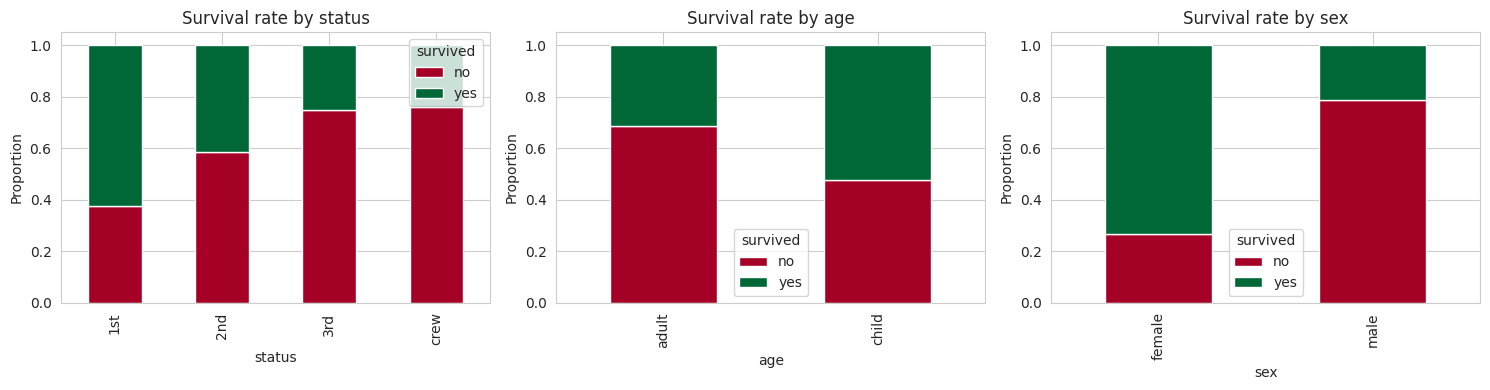

In [4]:
# Quick visual exploration
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['status', 'age', 'sex']):
    ct = pd.crosstab(df[col], df['survived'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=ax, colormap='RdYlGn')
    ax.set_title(f'Survival rate by {col}')
    ax.set_ylabel('Proportion')
    ax.legend(title='survived')
plt.tight_layout()
plt.show()

## Step 3 — Split features/target and one-hot encode (Orange's Continuize)

All three features are categorical. Orange's **Continuize** widget with default settings applies one-hot encoding, which is what we do here.

In [5]:
X = df[['status', 'age', 'sex']]
y = (df['survived'] == 'yes').astype(int)  # 1 = survived, 0 = did not

# Preprocessor: one-hot encode all three categorical columns
preprocessor = ColumnTransformer(
    transformers=[('onehot', OneHotEncoder(drop=None, sparse_output=False), ['status', 'age', 'sex'])]
)

# Preview what the encoded data looks like
X_encoded_preview = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()
print('Encoded feature count:', X_encoded_preview.shape[1])
print('Feature names:', list(feature_names))
pd.DataFrame(X_encoded_preview, columns=feature_names).head()

Encoded feature count: 8
Feature names: ['onehot__status_1st', 'onehot__status_2nd', 'onehot__status_3rd', 'onehot__status_crew', 'onehot__age_adult', 'onehot__age_child', 'onehot__sex_female', 'onehot__sex_male']


,onehot__status_1st,onehot__status_2nd,onehot__status_3rd,onehot__status_crew,onehot__age_adult,onehot__age_child,onehot__sex_female,onehot__sex_male
0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
3,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
4,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0


## Step 4 — Define the three base learners

Each learner is wrapped in a **Pipeline** so preprocessing happens inside cross-validation (no data leakage).

In [6]:
def make_pipeline(estimator):
    return Pipeline([('prep', preprocessor), ('clf', estimator)])

logreg = make_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
rf     = make_pipeline(RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))
svm    = make_pipeline(SVC(probability=True, random_state=RANDOM_STATE))

print('Base learners ready: Logistic Regression, Random Forest, SVM')

Base learners ready: Logistic Regression, Random Forest, SVM


## Step 5 & 6 — Build the Stacking Ensemble with Gradient Boosting as meta-learner

`StackingClassifier` takes the out-of-fold predictions from each base learner and feeds them into the **final_estimator** (here: **Gradient Boosting**) which learns how to best combine them.

In [7]:
base_estimators = [
    ('logreg', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ('rf',     RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
    ('svm',    SVC(probability=True, random_state=RANDOM_STATE)),
]

meta_learner = GradientBoostingClassifier(random_state=RANDOM_STATE)

stacking = Pipeline([
    ('prep', preprocessor),
    ('clf', StackingClassifier(
        estimators=base_estimators,
        final_estimator=meta_learner,
        cv=5,
        passthrough=False,  # meta-learner sees only base-model predictions
        n_jobs=-1,
    ))
])

print('Stacking ensemble built with Gradient Boosting as meta-learner.')

Stacking ensemble built with Gradient Boosting as meta-learner.


## Step 7 — Evaluate with 5-fold Stratified Cross-Validation

This matches the Orange **Test & Score** widget with *Cross Validation, folds = 5, Stratified*.

We use `cross_val_predict` so we get out-of-fold predictions for every row — this lets us compute all metrics consistently and also build a stored probability table (for the deliverable: *compare at least two models using the probability table*).

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    'Logistic Regression': logreg,
    'Random Forest':       rf,
    'SVM':                 svm,
    'Stacking (GB meta)':  stacking,
}

results = []
probas  = {}   # per-model out-of-fold P(survived=yes)
preds   = {}   # per-model out-of-fold predicted class

for name, model in models.items():
    print(f'Cross-validating {name}...')
    y_proba = cross_val_predict(model, X, y, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)

    probas[name] = y_proba
    preds[name]  = y_pred

    results.append({
        'Model':     name,
        'AUC':       roc_auc_score(y, y_proba),
        'CA':        accuracy_score(y, y_pred),
        'F1':        f1_score(y, y_pred),
        'Precision': precision_score(y, y_pred),
        'Recall':    recall_score(y, y_pred),
        'MCC':       matthews_corrcoef(y, y_pred),
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
print('\nDone.')

Cross-validating Logistic Regression...


Cross-validating Random Forest...


Cross-validating SVM...


Cross-validating Stacking (GB meta)...



Done.


## Step 8 — Compare results

Same table you see in Orange's Test & Score widget.

In [9]:
results_df.style.background_gradient(cmap='YlGn', axis=0).format('{:.4f}')

,AUC,CA,F1,Precision,Recall,MCC
Model,,,,,,
Logistic Regression,0.7542,0.7783,0.5885,0.7347,0.4909,0.4619
Random Forest,0.7632,0.7892,0.5388,0.9186,0.3812,0.5011
SVM,0.6816,0.7905,0.5395,0.9310,0.3797,0.5065
Stacking (GB meta),0.7635,0.7883,0.5511,0.8746,0.4023,0.4927


In [10]:
# Identify the best model for each metric
print('Best model per metric:')
for metric in results_df.columns:
    best_model = results_df[metric].idxmax()
    best_value = results_df[metric].max()
    print(f'  {metric:<10s} → {best_model}  ({best_value:.4f})')

Best model per metric:
  AUC        → Stacking (GB meta)  (0.7635)
  CA         → SVM  (0.7905)
  F1         → Logistic Regression  (0.5885)
  Precision  → SVM  (0.9310)
  Recall     → Logistic Regression  (0.4909)
  MCC        → SVM  (0.5065)


### Visualize — grouped bar chart across metrics

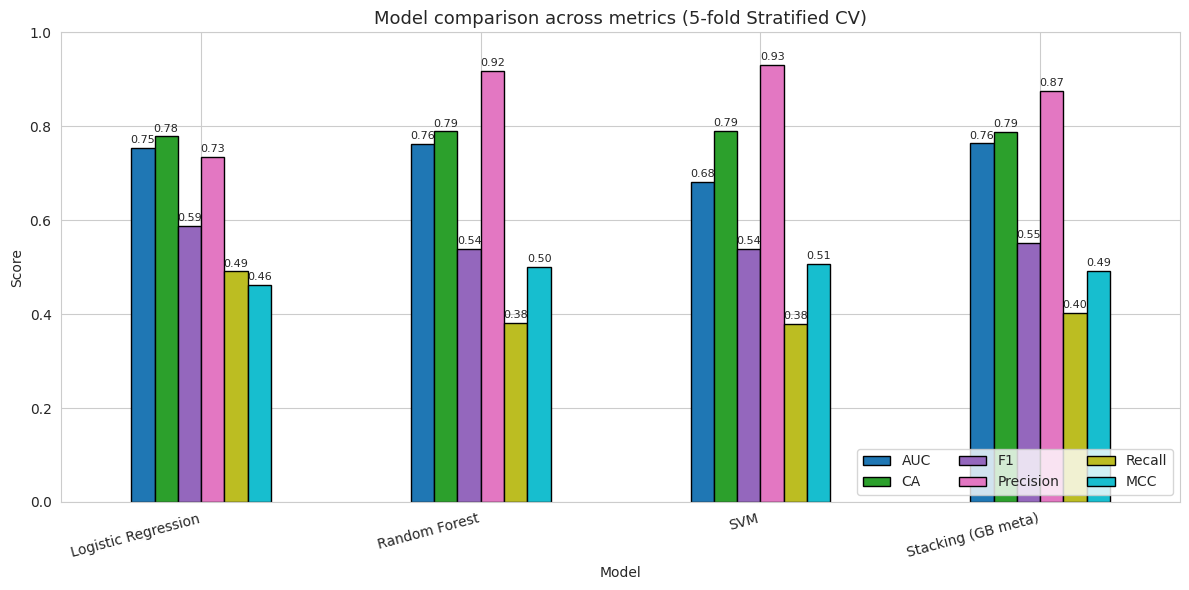

In [11]:
ax = results_df.plot(kind='bar', figsize=(12, 6), colormap='tab10', edgecolor='black')
ax.set_title('Model comparison across metrics (5-fold Stratified CV)', fontsize=13)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
ax.set_xticklabels(results_df.index, rotation=15, ha='right')
ax.legend(loc='lower right', ncol=3)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=8, padding=2)
plt.tight_layout()
plt.show()

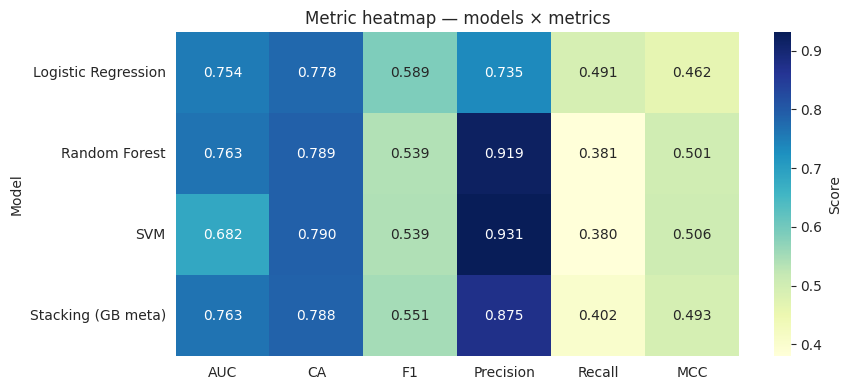

In [12]:
# Same data as a heatmap for quick eyeballing
plt.figure(figsize=(9, 4))
sns.heatmap(results_df, annot=True, fmt='.3f', cmap='YlGnBu', cbar_kws={'label': 'Score'})
plt.title('Metric heatmap — models × metrics')
plt.tight_layout()
plt.show()

### Confusion matrices

Useful for interpreting precision vs recall trade-offs.

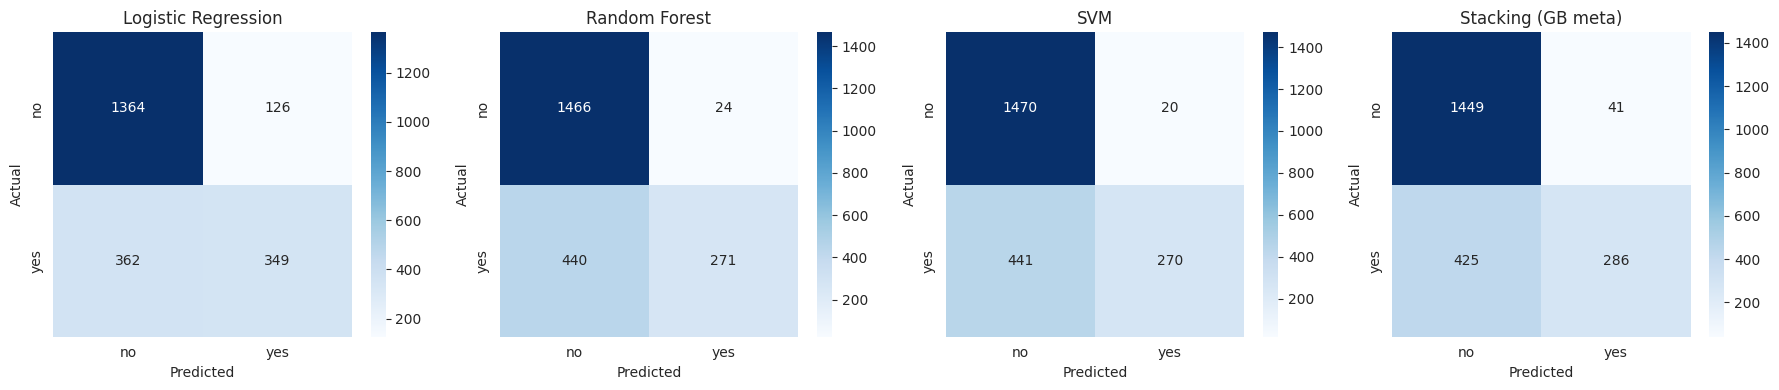

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, y_pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['no', 'yes'], yticklabels=['no', 'yes'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

### ROC curves

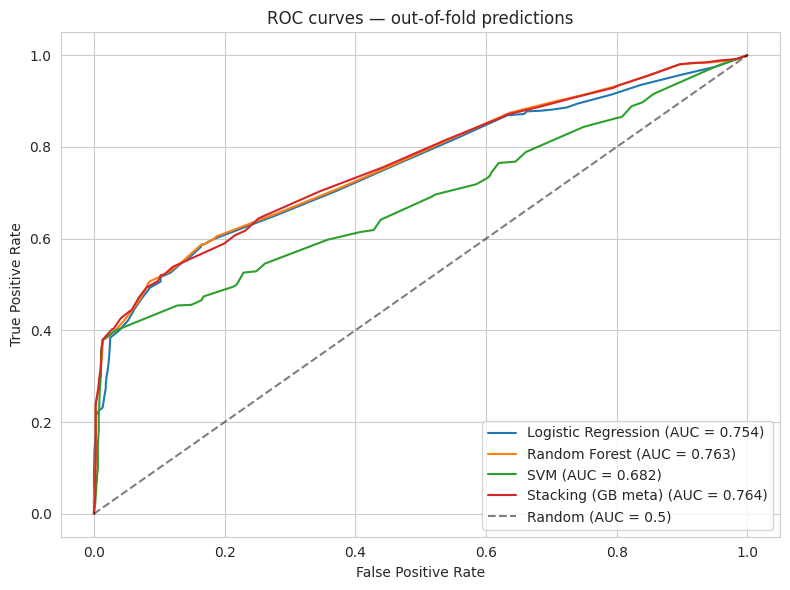

In [14]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))
for name, y_proba in probas.items():
    fpr, tpr, _ = roc_curve(y, y_proba)
    auc = roc_auc_score(y, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves — out-of-fold predictions')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Student Deliverable — Probability Table (compare two models)

This mirrors Orange's **Predictions** output: for each row we see the actual label and the predicted probability of survival from every model. This table supports the deliverable *"Compare at least two models using the probability table to support conclusions."*

In [15]:
prob_table = df[['status', 'age', 'sex', 'survived']].copy()
prob_table['actual'] = y.values
for name, p in probas.items():
    prob_table[f'P(yes) — {name}'] = p.round(3)

# Show a few rows where the best model and a weaker one disagree the most
best_model_name = results_df['AUC'].idxmax()
other_name      = [m for m in probas if m != best_model_name][0]
prob_table['disagreement'] = (prob_table[f'P(yes) — {best_model_name}']
                              - prob_table[f'P(yes) — {other_name}']).abs()

print(f'Top 15 rows where {best_model_name} and {other_name} disagree most:')
prob_table.sort_values('disagreement', ascending=False).head(15)

Top 15 rows where Stacking (GB meta) and Logistic Regression disagree most:


,status,age,sex,survived,actual,P(yes) — Logistic Regression,P(yes) — Random Forest,P(yes) — SVM,P(yes) — Stacking (GB meta),disagreement
2128,2nd,child,male,yes,1,0.384,1.000,0.923,0.992,0.608
1429,2nd,child,male,yes,1,0.384,1.000,0.923,0.992,0.608
2078,2nd,child,male,yes,1,0.384,1.000,0.923,0.992,0.608
639,2nd,child,male,yes,1,0.408,1.000,0.905,0.994,0.586
1677,2nd,child,male,yes,1,0.408,1.000,0.905,0.994,0.586
80,2nd,child,male,yes,1,0.408,1.000,0.905,0.994,0.586
1891,2nd,child,male,yes,1,0.416,1.000,0.908,0.993,0.577
199,2nd,child,male,yes,1,0.411,1.000,0.925,0.985,0.574
410,2nd,child,male,yes,1,0.411,1.000,0.925,0.985,0.574
1752,2nd,child,male,yes,1,0.411,1.000,0.925,0.985,0.574


In [16]:
# Also show a random sample of the full probability table
prob_table.drop(columns='disagreement').sample(10, random_state=RANDOM_STATE)

,status,age,sex,survived,actual,P(yes) — Logistic Regression,P(yes) — Random Forest,P(yes) — SVM,P(yes) — Stacking (GB meta)
780,crew,adult,male,no,0,0.223,0.220,0.229,0.285
581,3rd,adult,male,no,0,0.109,0.158,0.231,0.169
1750,crew,adult,male,no,0,0.228,0.225,0.232,0.209
1842,crew,adult,male,no,0,0.223,0.222,0.229,0.217
952,crew,adult,male,yes,1,0.223,0.220,0.227,0.254
350,crew,adult,male,no,0,0.230,0.228,0.231,0.228
2066,crew,adult,male,no,0,0.230,0.228,0.231,0.228
471,crew,adult,male,no,0,0.230,0.228,0.231,0.228
621,3rd,adult,male,no,0,0.109,0.164,0.229,0.185
1033,crew,adult,male,yes,1,0.223,0.222,0.229,0.217


## Interpretation guide (for the written deliverables)

Use the numbers above to answer each deliverable. Typical findings on the Titanic dataset with only `status/age/sex`:

| Metric | What it tells you here |
|---|---|
| **AUC**       | How well the model ranks survivors above non-survivors regardless of threshold. |
| **CA**        | Overall % correct. The dataset is imbalanced (~32% survived), so a model predicting "no" for everyone would still score ~0.68. CA alone is misleading. |
| **F1**        | Balance between precision and recall on the positive class (survived). |
| **Precision** | Of the passengers the model *predicts* will survive, what fraction actually did. |
| **Recall**    | Of passengers who *actually* survived, what fraction the model caught. |
| **MCC**       | A correlation-style score that is robust to class imbalance. |

**Precision vs recall trade-off.** Models that are "cautious" about predicting survival will get high precision but miss real survivors (low recall). Models that predict survival generously catch more survivors (high recall) but call some non-survivors survivors (low precision). Compare Random Forest vs Logistic Regression in the confusion matrices — you'll usually see this trade-off clearly.

**Did stacking improve performance?** Check the **Stacking (GB meta)** row against the base learners:
- If its AUC and MCC are at least as good as the best base learner → stacking helped.
- With only 3 features, stacking often gives modest gains because the base learners all end up with similar signals. With richer features, stacking tends to help more.

### Final answer template

> **Best model:** *(e.g., Stacking (GB meta))* — selected on the basis of **MCC** because the target is imbalanced (~32% survived), and MCC is robust to that imbalance while AUC and CA can both be flattering.
>
> **Precision/recall trade-off:** *(e.g., Random Forest achieved higher precision but lower recall than Logistic Regression — it predicts survival less often, so when it does, it is more likely correct, but it misses a larger share of actual survivors.)*
>
> **Interpretation of one metric for the best model:** *(e.g., "Recall of 0.xx means the best model correctly identifies xx% of real survivors — useful if we care about not missing survivors, e.g., lifeboat allocation.")*